# XGBoost Hyperparameter Investigation

### Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

sns.set_style("whitegrid")
sns.set_palette("colorblind")

plt.rcParams["figure.figsize"] = (10,6)

### Load the dataset

In [23]:
df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### dataset overview

In [24]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Encode Categorical Variables

In [25]:
label_encoders = {}

for column in df.select_dtypes(include=["object"]).columns:

    le = LabelEncoder()

    df[column] = le.fit_transform(df[column])

    label_encoders[column] = le

### Target Distribution

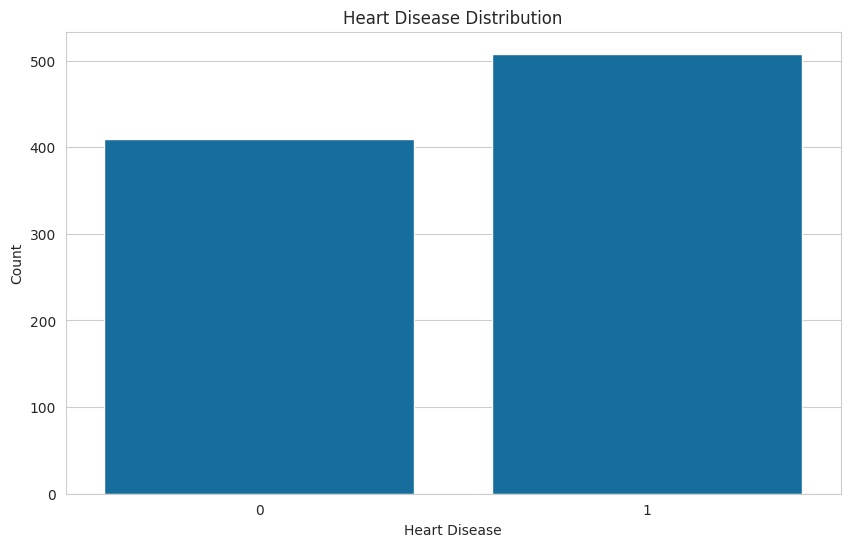

In [26]:
sns.countplot(x="HeartDisease", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.savefig("figure1_target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Define Features and Target

In [27]:
X = df.drop("HeartDisease", axis=1)

y = df["HeartDisease"]

### Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### XGBoost Model

In [29]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

preds = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Baseline XGBoost Accuracy:", accuracy)

Baseline XGBoost Accuracy: 0.8804347826086957


### Investigating Tree Depth

In [30]:
depth_values = [2,3,4,5,6]

depth_scores = []

for depth in depth_values:

    model = XGBClassifier(
        n_estimators=200,
        max_depth=depth,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test, pred)

    depth_scores.append(score)

### Plot Tree Depth Effect

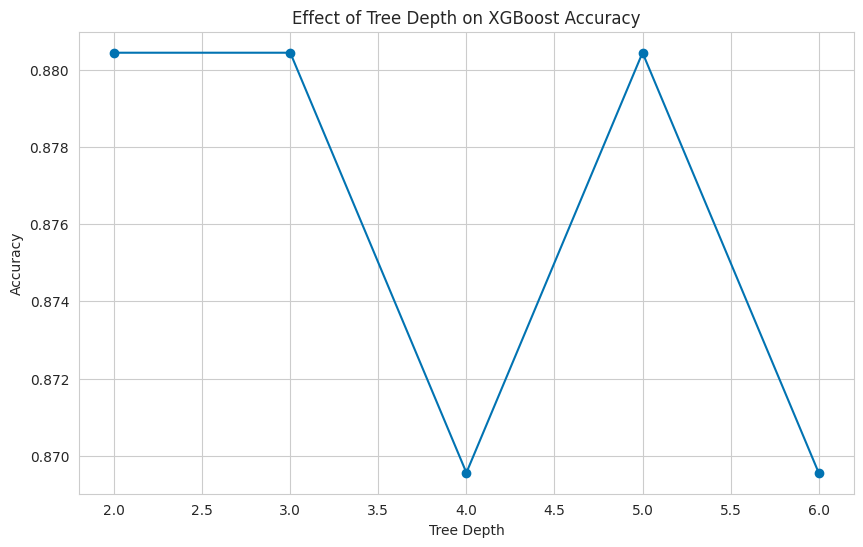

In [31]:
plt.plot(depth_values, depth_scores, marker="o")

plt.title("Effect of Tree Depth on XGBoost Accuracy")

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("figure2_tree_depth_effect.png", dpi=300, bbox_inches="tight")

plt.show()

### Investigating Learning Rate

In [32]:
learning_rates = [0.01,0.05,0.1,0.2,0.3]

lr_scores = []

for lr in learning_rates:

    model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=lr,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test, pred)

    lr_scores.append(score)

### Plot Learning Rate Effect

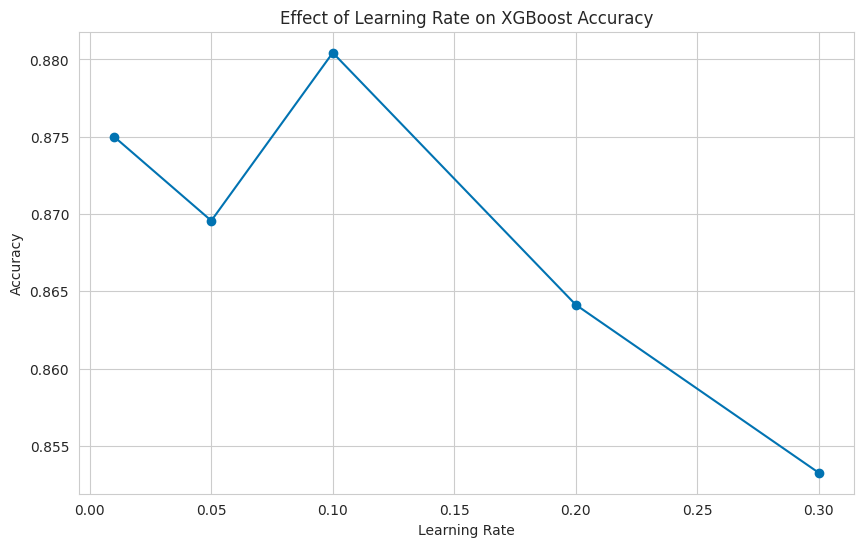

In [33]:
plt.plot(learning_rates, lr_scores, marker="o")

plt.title("Effect of Learning Rate on XGBoost Accuracy")

plt.xlabel("Learning Rate")

plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("figure3_learning_rate_effect.png", dpi=300, bbox_inches="tight")

plt.show()

### Training Curves

In [34]:
eval_set = [(X_train, y_train), (X_test, y_test)]

xgb_curve_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_curve_model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### Extract Training Results

In [35]:
results = xgb_curve_model.evals_result()

train_loss = results["validation_0"]["logloss"]
test_loss = results["validation_1"]["logloss"]

### Plot Training Curve

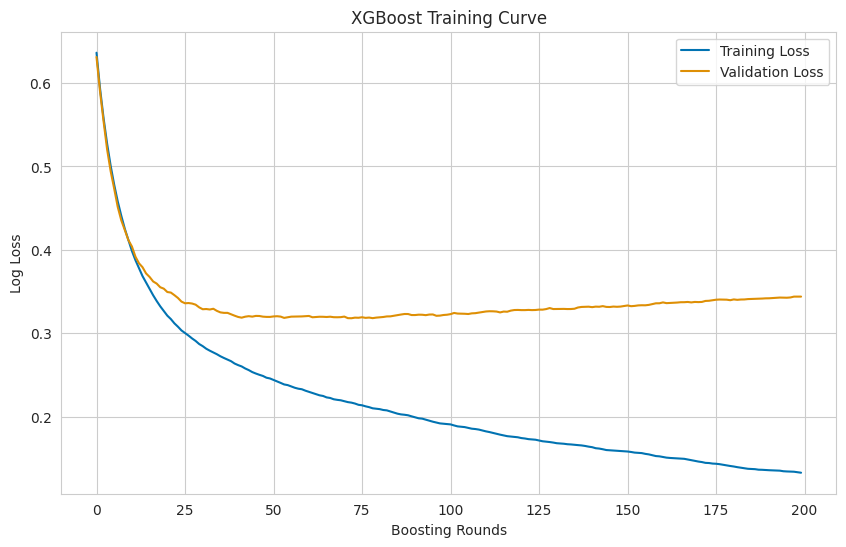

In [36]:
epochs = range(len(train_loss))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, test_loss, label="Validation Loss")

plt.title("XGBoost Training Curve")

plt.xlabel("Boosting Rounds")

plt.ylabel("Log Loss")

plt.legend()

plt.grid(True)

plt.savefig("figure4_training_curve.png", dpi=300, bbox_inches="tight")

plt.show()

### Hyperparameter Interaction Heatmap

In [37]:
depth_grid = [2,3,4,5,6]

learning_rate_grid = [0.01,0.05,0.1,0.2]

heatmap_results = []

for depth in depth_grid:

    row_scores = []

    for lr in learning_rate_grid:

        model = XGBClassifier(
            n_estimators=200,
            max_depth=depth,
            learning_rate=lr,
            random_state=42,
            eval_metric="logloss"
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        score = accuracy_score(y_test, pred)

        row_scores.append(score)

    heatmap_results.append(row_scores)

### Plot Hyperparameter Heatmap

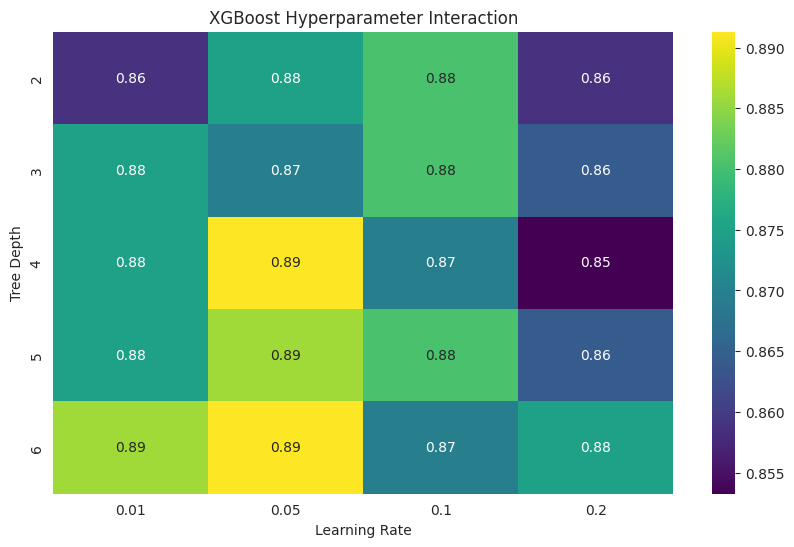

In [38]:
heatmap_df = pd.DataFrame(
    heatmap_results,
    index=depth_grid,
    columns=learning_rate_grid
)
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="viridis"
)

plt.title("XGBoost Hyperparameter Interaction")

plt.xlabel("Learning Rate")

plt.ylabel("Tree Depth")

plt.savefig("figure5_hyperparameter_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### COnfusion Matrix

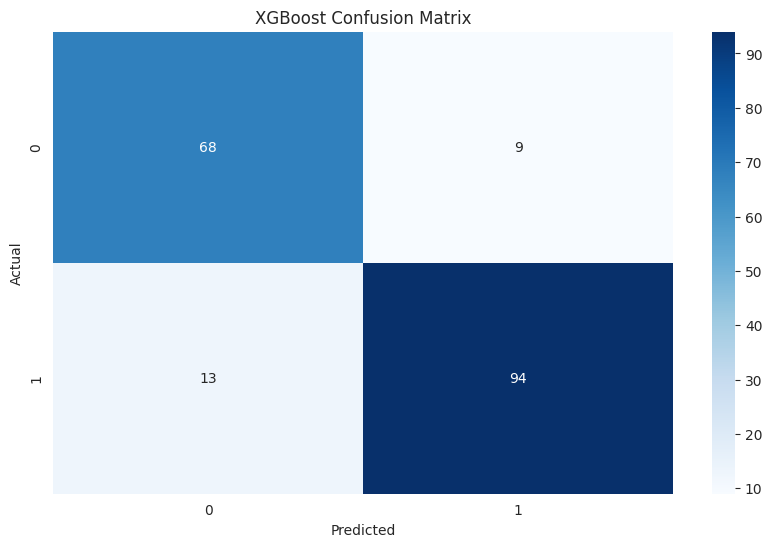

In [39]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("figure5_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [40]:
print(classification_report(
    y_test,
    preds,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

